In [ ]:
pip install wget gdown

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=06946bde2c42e757216a1c04645203c241219999e9ade259e9add5a4633a3e86
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [ ]:
import gdown
gdown.download(id="1_MFvRhEi4g28V9xbTCDKA13SeR1K9SgF", output="tbc_dataset.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1_MFvRhEi4g28V9xbTCDKA13SeR1K9SgF
From (redirected): https://drive.google.com/uc?id=1_MFvRhEi4g28V9xbTCDKA13SeR1K9SgF&confirm=t&uuid=1080bebc-ace0-4d88-b709-e0cfb633bbec
To: /content/tbc_dataset.zip
100%|██████████| 121M/121M [00:03<00:00, 37.1MB/s]


'tbc_dataset.zip'

In [ ]:
import zipfile
zip_path = "tbc_dataset.zip"
extract_to ="./"

try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Selesai extract ke:", extract_to)
except zipfile.BadZipFile:
    print(f"Error: The file '{zip_path}' is not a valid zip file. Please check if the download was successful and the file is not corrupted.")
except FileNotFoundError:
    print(f"Error: The file '{zip_path}' was not found. Please ensure it has been downloaded.")

Selesai extract ke: ./


## Data Preparation

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier # Added for Random Forest
from sklearn.metrics import classification_report, confusion_matrix
import joblib
from skimage import exposure

In [ ]:
 # Function for lung segmentation
 def lung_segmentation(image_gray):
     # Apply CLAHE for contrast enhancement
     clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
     cl1 = clahe.apply(image_gray)

     # Apply adaptive thresholding to get a binary image
     thresh = cv2.adaptiveThreshold(cl1, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY_INV, 11, 2)

     # Morphological operations
     # Erosion followed by dilation to remove small noise (opening)
     kernel = np.ones((5,5), np.uint8)
     opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

     # Dilation followed by erosion to fill small holes (closing)
     closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=2)

     # Find contours
     contours, hierarchy = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

     # Create an empty mask
     lung_mask = np.zeros_like(image_gray, dtype=np.uint8)

     if contours:
         # Sort contours by area and get the two largest (assumed to be lungs)
         # This assumes that the lungs are the two largest connected components
         contours = sorted(contours, key=cv2.contourArea, reverse=True)[:2]

         # Draw the two largest contours on the mask
         cv2.drawContours(lung_mask, contours, -1, (255), thickness=cv2.FILLED)

     # Apply the mask to the original grayscale image
     segmented_lungs = cv2.bitwise_and(image_gray, image_gray, mask=lung_mask)

     return segmented_lungs, lung_mask


In [ ]:
# Constants and configuration
IMAGE_SIZE = (64, 64)  # Resize images to 64x64 for consistency
ORIENTATIONS = 9
PIXELS_PER_CELL = (8, 8)
CELLS_PER_BLOCK = (2, 2)
TEST_SIZE = 0.2
RANDOM_STATE = 42
DATASET_DIR = 'tbc_dataset.zip'

In [ ]:
# Function to load an image
def load_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print('Error: Could not load image.')
        return None, None
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image, gray

In [ ]:
# HOG feature extraction function
def extract_hog_features(image_gray):
    features, hog_image = hog(
        image_gray,
        orientations=ORIENTATIONS,
        pixels_per_cell=PIXELS_PER_CELL,
        cells_per_block=CELLS_PER_BLOCK,
        block_norm='L2-Hys',
        visualize=True,
        feature_vector=True
    )
    return features, hog_image

In [ ]:
# Function to crop the image from nose to mouth region
def crop_half_image(img, bottom=True):
    h = img.shape[0]
    mid = h // 2
    if bottom:
        cropped = img[mid:, :]
    else:
        cropped = img[:mid, :]
    return cropped

In [ ]:
# Load the dataset and extract HOG features
X = []
y = []  # This is list of labels
hog_img = []

DATASET_DIR = '.'

for root, dirs, files in os.walk(DATASET_DIR):
    folder_name = os.path.basename(root)
    if folder_name not in ["Normal", "Tuberculosis"]:
        continue

    print(f"Processing {root}...")

    for f in files:
        if not (f.lower().endswith(('.png', '.jpg', '.jpeg'))):
            continue

        image_path = os.path.join(root, f)
        image_rgb, image_gray = load_image(image_path)

        if image_gray is None:
            continue

        # SEGMENTATION-BASED BOUNDING BOX
        try:
            # 1. Get the mask
            _, lung_mask = lung_segmentation(image_gray)

            # 2. Find the bounding box
            points = cv2.findNonZero(lung_mask)

            if points is not None:
                # FIX: Renamed variables to bx, by, bw, bh to avoid conflict with 'y' list
                bx, by, bw, bh = cv2.boundingRect(points)

                # 3. Crop using the new variable names
                pad = 5
                bx = max(0, bx - pad)
                by = max(0, by - pad)
                bw = min(image_gray.shape[1] - bx, bw + 2*pad)
                bh = min(image_gray.shape[0] - by, bh + 2*pad)

                img_final = image_gray[by:by+bh, bx:bx+bw]
            else:
                #print(f"Warning: Segmentation empty for {f}. Using full image.")
                img_final = image_gray

        except Exception as e:
            print(f"Error processing {f}: {e}")
            img_final = image_gray


        # Resize to 64x64
        roi_resized = cv2.resize(img_final, IMAGE_SIZE, interpolation=cv2.INTER_AREA)

        # Extract HOG features
        hog_feature, hog_maps = extract_hog_features(roi_resized)

        if hog_feature is None:
            continue

        hog_img.append(hog_maps)
        X.append(hog_feature)

        if folder_name == "Normal":
            y.append(0)
        elif folder_name == "Tuberculosis":
            y.append(1)

X = np.array(X)
y = np.array(y)
print(f"[INFO] Processing Complete. Total samples: {X.shape[0]}, Feature dimension: {X.shape[1]}")

Processing ./Tuberculosis...
Processing ./Normal...
[INFO] Processing Complete. Total samples: 800, Feature dimension: 1764


## Data Splitting and Feature Scaling

In [ ]:
# Split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## Training and Evaluate

In [ ]:
# Train the SVM model
clf = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
print("[INFO] Training SVM...")
clf.fit(X_train_s, y_train)

[INFO] Training SVM...


SVC(probability=True, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
# Evaluate the model
y_pred = clf.predict(X_test_s)
print("\n[RESULT] Classification report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "TB Positive"]))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# Calculate AUC
if hasattr(clf, "predict_proba"):
    y_prob = clf.predict_proba(X_test_s)[:, 1] # Probability of positive class
    auc = roc_auc_score(y_test, y_prob)
    print(f"AUC: {auc:.4f}")
else:
    print("AUC cannot be calculated: Estimator does not have 'predict_proba' method.")


[RESULT] Classification report:
              precision    recall  f1-score   support

      Normal       0.90      0.75      0.82        80
 TB Positive       0.78      0.91      0.84        80

    accuracy                           0.83       160
   macro avg       0.84      0.83      0.83       160
weighted avg       0.84      0.83      0.83       160

Confusion matrix:
[[60 20]
 [ 7 73]]
AUC: 0.9077


In [ ]:
# Save the model and scaler
MODEL_PATH = "svm_tb_model.pkl"
joblib.dump({"model": clf, "scaler": scaler}, MODEL_PATH)
print(f"[INFO] Model saved to: {MODEL_PATH}")

[INFO] Model saved to: svm_tb_model.pkl


## Prediction on New Image

In [ ]:
# Function to predict a single image
def predict_image(image, features, model_path):
    data = joblib.load(model_path)
    model_loaded = data.get("model")
    scaler = data.get("scaler")

    if scaler is not None:
        features = scaler.transform(features)

    pred = model_loaded.predict(features)[0]
    conf = None
    prob = 0
    prob = model_loaded.predict_proba(features)[0] if hasattr(model_loaded, "predict_proba") else None
    conf = float(max(prob))

    label_str = "TB Positive" if pred == 1 else "Normal"
    print(f"Prediction: {label_str}")
    return draw_result(image, conf, label_str)


In [ ]:
# Function to draw the result on the image
def draw_text(image, label, score, pos=(10, 30)):
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.6
    font_thickness = 2
    text_color = (255, 255, 255)
    text_color_bg = (0, 0, 255)

    score_text = f'Score: {score:.2f}'
    (w1, h1), _ = cv2.getTextSize(score_text, font, font_scale, font_thickness)
    (w2, h2), _ = cv2.getTextSize(label, font, font_scale, font_thickness)

    box_width = max(w1, w2) + 20
    box_height = h1 + h2 + 25

    x, y = pos
    x = max(0, x)
    y = max(box_height, y)

    cv2.rectangle(image, (x, y - box_height), (x + box_width, y), text_color_bg, -1)
    cv2.putText(image, label, (x + 10, y - h1 - 10), font, font_scale, text_color, font_thickness)
    cv2.putText(image, score_text, (x + 10, y - 10), font, font_scale, text_color, font_thickness)

def draw_result(image_bgr, score, label):
    result_image = image_bgr.copy()
    draw_text(result_image, label, score, pos=(10, 40))
    return result_image


## Testing

Prediction: Normal


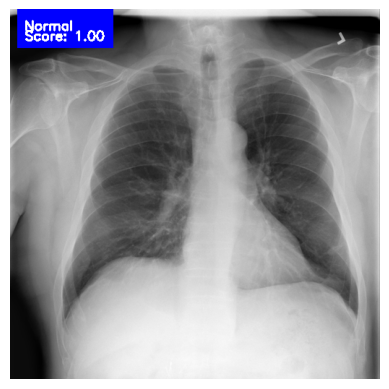

In [ ]:
# Test prediction (SVM)
TESTING_IMAGE = "./Normal/Normal-2.png" # Update path if needed
image_rgb, image_gray = load_image(TESTING_IMAGE)

if image_gray is None:
    print(f"Error: Failed to load {TESTING_IMAGE}")
else:

    _, lung_mask = lung_segmentation(image_gray)
    points = cv2.findNonZero(lung_mask)

    if points is not None:
        x, y, w, h = cv2.boundingRect(points)
        pad = 5
        x = max(0, x - pad)
        y = max(0, y - pad)
        w = min(image_gray.shape[1] - x, w + 2*pad)
        h = min(image_gray.shape[0] - y, h + 2*pad)
        img_final = image_gray[y:y+h, x:x+w]
    else:
        img_final = image_gray

    roi_resized = cv2.resize(img_final, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
    hog_feature, _ = extract_hog_features(roi_resized)

    if hog_feature is not None:
        hog_feature = hog_feature.reshape(1, -1)
        result_image = predict_image(image_rgb, hog_feature, MODEL_PATH)
        plt.imshow(result_image)
        plt.axis('off')
        plt.show()

Prediction: TB Positive


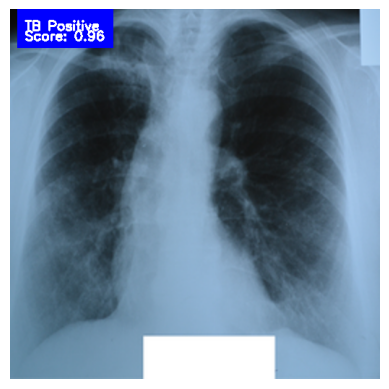

In [ ]:
# Test prediction (SVM)
TESTING_IMAGE = "./Tuberculosis/Tuberculosis-1.png" # Update path if needed
image_rgb, image_gray = load_image(TESTING_IMAGE)

if image_gray is None:
    print(f"Error: Failed to load {TESTING_IMAGE}")
else:

    _, lung_mask = lung_segmentation(image_gray)
    points = cv2.findNonZero(lung_mask)

    if points is not None:
        x, y, w, h = cv2.boundingRect(points)
        pad = 5
        x = max(0, x - pad)
        y = max(0, y - pad)
        w = min(image_gray.shape[1] - x, w + 2*pad)
        h = min(image_gray.shape[0] - y, h + 2*pad)
        img_final = image_gray[y:y+h, x:x+w]
    else:
        img_final = image_gray


    roi_resized = cv2.resize(img_final, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
    hog_feature, _ = extract_hog_features(roi_resized)

    if hog_feature is not None:
        hog_feature = hog_feature.reshape(1, -1)
        result_image = predict_image(image_rgb, hog_feature, MODEL_PATH)
        plt.imshow(result_image)
        plt.axis('off')
        plt.show()

In [ ]:
# Test prediction on a single image
TESTING_IMAGE = "paru.jpg"  # Changed to a valid image path from the extracted dataset
image_rgb, image_gray = load_image(TESTING_IMAGE)

# Check if image_gray was loaded successfully before proceeding
if image_gray is None:
    print(f"Error: Failed to load image from {TESTING_IMAGE}. Please ensure the path is correct and the image exists.")
else:
    # Replicate preprocessing steps from training data pipeline
    img_crop = crop_half_image(image_gray, bottom=True)

    if img_crop is None or img_crop.size == 0 or img_crop.shape[0] < 4 or img_crop.shape[1] < 4:
        img_crop = image_gray  # Fallback to full image if crop is invalid or too small

    # Resize to IMAGE_SIZE before HOG feature extraction
    roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA)

    hog_feature, hog_maps = extract_hog_features(roi_resized) # Extract HOG from the preprocessed image

    if hog_feature is None:
        print(f"Error: Failed to extract HOG features from {TESTING_IMAGE}.")
    else:
        # Reshape hog_feature for single prediction if it's 1D
        if hog_feature.ndim == 1:
            hog_feature = hog_feature.reshape(1, -1)

        result_image = predict_image(image_rgb, hog_feature, MODEL_PATH)

        # Display the result
        plt.imshow(result_image)
        plt.axis('off') # Hide axes for cleaner display
        plt.show()

# Add Random Forest Model with Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# Define the parameter grid for Random Forest tuning
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]    # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    n_jobs=-1, # Use all available CPU cores
    verbose=2, # Display progress messages
    scoring='accuracy' # Optimize for accuracy
)

print("[INFO] Starting Random Forest hyperparameter tuning...")
grid_search.fit(X_train_s, y_train)

# Print best parameters and best score
print("\n[INFO] Best parameters found:", grid_search.best_params_)
print("[INFO] Best cross-validation accuracy:", grid_search.best_score_)

# Get the best estimator
rf_clf_tuned = grid_search.best_estimator_

[INFO] Starting Random Forest hyperparameter tuning...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

[INFO] Best parameters found: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
[INFO] Best cross-validation accuracy: 0.83125


## Evaluate

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
# Evaluate the tuned Random Forest model
y_pred_rf_tuned = rf_clf_tuned.predict(X_test_s)
print("\n[RESULT] Tuned Random Forest Classification report:")
print(classification_report(y_test, y_pred_rf_tuned, target_names=["Normal", "TB Positive"]))
print("Confusion matrix (Tuned Random Forest):")
print(confusion_matrix(y_test, y_pred_rf_tuned))

# Calculate AUC for Tuned Random Forest
if hasattr(rf_clf_tuned, "predict_proba"):
    y_prob_rf_tuned = rf_clf_tuned.predict_proba(X_test_s)[:, 1] # Probability of positive class
    auc_rf_tuned = roc_auc_score(y_test, y_prob_rf_tuned)
    print(f"AUC (Tuned Random Forest): {auc_rf_tuned:.4f}")
else:
    print("AUC cannot be calculated for Tuned Random Forest: Estimator does not have 'predict_proba' method.")


[RESULT] Tuned Random Forest Classification report:
              precision    recall  f1-score   support

      Normal       0.83      0.84      0.83        80
 TB Positive       0.84      0.82      0.83        80

    accuracy                           0.83       160
   macro avg       0.83      0.83      0.83       160
weighted avg       0.83      0.83      0.83       160

Confusion matrix (Tuned Random Forest):
[[67 13]
 [14 66]]
AUC (Tuned Random Forest): 0.9008


## Testing with Random Forest

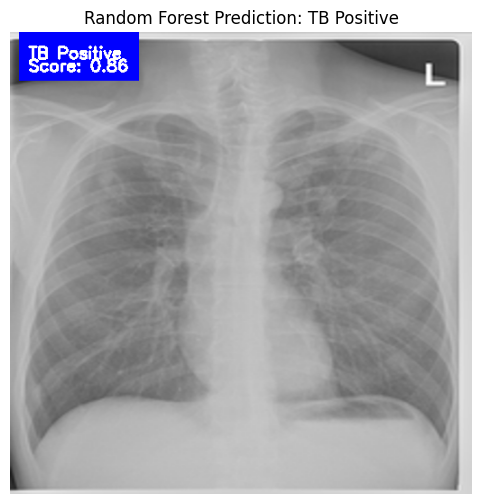

In [ ]:
# Test prediction on a single image (Random Forest Model)
TESTING_IMAGE_RF = "./Tuberculosis/Tuberculosis-60.png" # Change to valid path
image_rgb_rf, image_gray_rf = load_image(TESTING_IMAGE_RF)

if image_gray_rf is None:
    print(f"Error: Failed to load image from {TESTING_IMAGE_RF}")
else:

    try:
        segmented_img_rf, _ = lung_segmentation(image_gray_rf)

        if np.count_nonzero(segmented_img_rf) == 0:
            print("Warning: Segmentation failed. Using full image.")
            processed_img_rf = image_gray_rf
        else:
            processed_img_rf = segmented_img_rf

    except Exception as e:
        print(f"Error during segmentation: {e}. Using full image.")
        processed_img_rf = image_gray_rf


    # Resize
    roi_resized_rf = cv2.resize(processed_img_rf, IMAGE_SIZE, interpolation=cv2.INTER_AREA)

    # Extract HOG
    hog_feature_rf, _ = extract_hog_features(roi_resized_rf)

    if hog_feature_rf is None:
        print("Error: Failed to extract HOG features.")
    else:
        # Reshape
        hog_feature_rf = hog_feature_rf.reshape(1, -1)

        # Scale features using the SAME scaler from training
        # (Assuming 'scaler' is still in memory from the training step)
        if 'scaler' in globals():
            hog_feature_rf = scaler.transform(hog_feature_rf)

        # Predict using the Tuned Random Forest model
        if 'rf_clf_tuned' in globals():
            pred_rf = rf_clf_tuned.predict(hog_feature_rf)[0]
            prob_rf = rf_clf_tuned.predict_proba(hog_feature_rf)[0]
            conf_rf = float(max(prob_rf))

            label_str_rf = "TB Positive" if pred_rf == 1 else "Normal"

            # Draw result
            res_img_rf = draw_result(image_rgb_rf, conf_rf, label_str_rf)

            plt.figure(figsize=(6,6))
            plt.imshow(res_img_rf)
            plt.axis('off')
            plt.title(f"Random Forest Prediction: {label_str_rf}")
            plt.show()
        else:
            print("Error: 'rf_clf_tuned' model not found. Run the training cell first.")

In [ ]:
# Test prediction on a single image
TESTING_IMAGE = "paru.jpg"  # Changed to a valid image path from the extracted dataset
image_rgb, image_gray = load_image(TESTING_IMAGE)

# Check if image_gray was loaded successfully before proceeding
if image_gray is None:
    print(f"Error: Failed to load image from {TESTING_IMAGE}. Please ensure the path is correct and the image exists.")
else:
    # Replicate preprocessing steps from training data pipeline
    img_crop = crop_half_image(image_gray, bottom=True)

    if img_crop is None or img_crop.size == 0 or img_crop.shape[0] < 4 or img_crop.shape[1] < 4:
        img_crop = image_gray  # Fallback to full image if crop is invalid or too small

    # Resize to IMAGE_SIZE before HOG feature extraction
    roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA)

    hog_feature, hog_maps = extract_hog_features(roi_resized) # Extract HOG from the preprocessed image

    if hog_feature is None:
        print(f"Error: Failed to extract HOG features from {TESTING_IMAGE}.")
    else:
        # Reshape hog_feature for single prediction if it's 1D
        if hog_feature.ndim == 1:
            hog_feature = hog_feature.reshape(1, -1)

        result_image = predict_image(image_rgb, hog_feature, MODEL_PATH)

        # Display the result
        plt.imshow(result_image)
        plt.axis('off') # Hide axes for cleaner display
        plt.show()